## 5. Renewables focus

In the previous exploratory data analysis, it has been found out the nregative relationship between renewables shares and energy prices, expressed by the negative moderated correlation of -0.39.  
This indicated that an increase of renewable shares describe a decrease of power prices.  
It is important to remind that correlation doesn't mean causation, but rather it is a description of the behavior of these two variables. 

In [14]:
# import libraries
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# filter User and Filter Warnings for privacy matters
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

# define clean dataset folder path
clean_dataset_path = Path('../dataset/clean')

# read merge-dataset
data = pd.read_csv(clean_dataset_path / 'merged-dataset.csv')

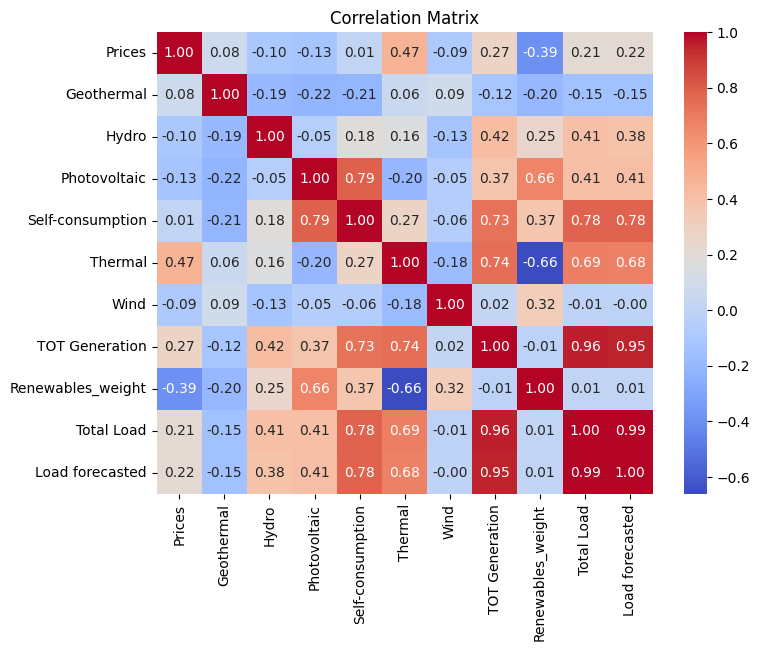

In [40]:
# correlation matrix
corr_matrix = data.corr(numeric_only=True)

# display heated matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

To further investigate the relationship about these two variable, a linear regression study is applied in order to find out more precisely how muche these variations happpen.

### Bivariate Linear Regression with OLS

In [16]:
data = data.rename(
    columns={'Renewables weight': 'Renewables_weight'}
)

data.head()

,Date,Prices,Geothermal,Hydro,Photovoltaic,Self-consumption,Thermal,Wind,TOT Generation,Renewables_weight,Total Load,Load forecasted
0,2021-01-01 00:00:00,50.87000,0.62,3.43,0.0,2.058,14.55,2.60,21.20,0.313679,24640.25075,24614.24975
1,2021-01-01 01:00:00,48.19000,0.62,3.03,0.0,1.952,13.68,2.75,20.08,0.318725,22909.00000,23971.99975
2,2021-01-01 02:00:00,44.67966,0.62,2.79,0.0,1.812,12.77,2.63,18.81,0.321106,21044.49975,22554.74950
3,2021-01-01 03:00:00,42.92193,0.62,2.60,0.0,1.735,12.12,2.62,17.96,0.325167,19907.99975,21153.49975
4,2021-01-01 04:00:00,40.39151,0.62,2.60,0.0,1.733,12.06,2.61,17.89,0.325880,19578.49950,20336.75000


In [41]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

VAR_X = 'Renewables_weight'
VAR_Y = 'Prices'

formula = f'{VAR_Y} ~ {VAR_X}'

model = smf.ols(formula, data=data).fit()
print(f'\nLinear Regression Model - Prices and Renewables (2021 - 2025)\n')
print(model.summary())


Linear Regression Model - Prices and Renewables (2021 - 2025)

                            OLS Regression Results                            
Dep. Variable:                 Prices   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     7949.
Date:                Wed, 17 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:44:48   Log-Likelihood:            -2.6231e+05
No. Observations:               43814   AIC:                         5.246e+05
Df Residuals:                   43812   BIC:                         5.246e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

#### Visualizations

In [20]:
params = model.params

# x values
ax_x = 'Renewables_weight'
x = np.linspace(0, data[ax_x].max(), 100)

# coefficients
b0 = model.params['Intercept']
b1 = model.params['Renewables_weight']

# f lines
y_d_0 = b0 + b1 * x 


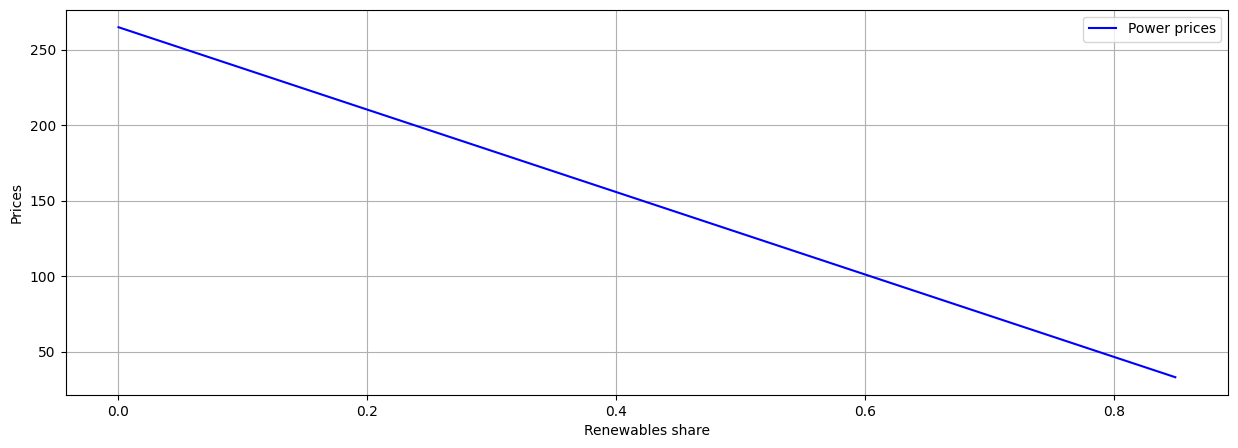

In [ ]:
# matplotlib graph
plt.figure(figsize=(15, 5))
# plt.plot(x, y_d_1, color='sandybrown', label='D = 1 (no interaction)', )
plt.plot(x, y_d_0, color='blue', label='Power prices')
# plt.plot(x, y_interaction, color='red', label='D = 1 (interaction)')
plt.xlabel("Renewables share")
plt.ylabel("Prices")
plt.legend()
plt.grid(True)
plt.show()

In [45]:
import plotly.express as px
import plotly.graph_objects as go 

fig = px.scatter(
    data, 
    x='Renewables_weight', 
    y='Prices', 
    hover_data={
        'Renewables_weight': True,
        'Prices': True, 
        'Date': True
    }, 
    opacity=0.05
)

fig.add_trace(
    go.Scatter(
        x=x,
        y=y_d_0,
        mode='lines',
        name='Power Prices',
        line=dict(width=4)
    )
)

fig.update_layout(
    title='Linear Regression (OLS)',
    xaxis_title='Renewables share',
    yaxis_title='Prices',
    template='simple_white'
)

fig.show()

### Renewables role in each power market regime



In [43]:
# define market regimes
data['Regime'] = np.where(data['Date'] < '2022-01-01', 'Pre-2022',
                   np.where(data['Date'] < '2023-01-01', '2022 Shock', 'Post-2022'))

data

,Date,Prices,Geothermal,Hydro,Photovoltaic,Self-consumption,Thermal,Wind,TOT Generation,Renewables_weight,Total Load,Load forecasted,Regime
0,2021-01-01 00:00:00,50.87000,0.62,3.43,0.0,2.058,14.55,2.60,21.20,0.313679,24640.25075,24614.24975,Pre-2022
1,2021-01-01 01:00:00,48.19000,0.62,3.03,0.0,1.952,13.68,2.75,20.08,0.318725,22909.00000,23971.99975,Pre-2022
2,2021-01-01 02:00:00,44.67966,0.62,2.79,0.0,1.812,12.77,2.63,18.81,0.321106,21044.49975,22554.74950,Pre-2022
3,2021-01-01 03:00:00,42.92193,0.62,2.60,0.0,1.735,12.12,2.62,17.96,0.325167,19907.99975,21153.49975,Pre-2022
4,2021-01-01 04:00:00,40.39151,0.62,2.60,0.0,1.733,12.06,2.61,17.89,0.325880,19578.49950,20336.75000,Pre-2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43809,2025-12-31 19:00:00,121.00000,0.60,3.75,0.0,3.419,22.65,2.33,29.33,0.227753,37002.25000,36421.74925,Post-2022
43810,2025-12-31 20:00:00,113.96499,0.60,2.82,0.0,3.145,21.33,2.08,26.83,0.204994,34212.50000,32732.99975,Post-2022
43811,2025-12-31 21:00:00,111.20000,0.60,2.11,0.0,2.691,20.11,1.67,24.49,0.178849,31110.24950,29597.99925,Post-2022
43812,2025-12-31 22:00:00,113.56500,0.60,1.78,0.0,2.427,18.65,1.36,22.39,0.167039,29077.25000,27451.50025,Post-2022


In [47]:
pre_2022 = data[data['Regime'] == 'Pre-2022'] 
during_2022 = data[data['Regime'] == '2022 Shock'] 
post_2022 = data[data['Regime'] == 'Post-2022']


In [49]:
# pre 2022 ols
model = smf.ols(formula, data=pre_2022).fit()
print(f'\nLinear Regression Model - Prices and Renewables (2021)\n')
print(model.summary())



Linear Regression Model - Prices and Renewables (2021)

                            OLS Regression Results                            
Dep. Variable:                 Prices   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     1591.
Date:                Wed, 17 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:57:08   Log-Likelihood:                -50196.
No. Observations:                8758   AIC:                         1.004e+05
Df Residuals:                    8756   BIC:                         1.004e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

In [51]:
# 2022 ols
model = smf.ols(formula, data=during_2022).fit()
print(f'\nLinear Regression Model - Prices and Renewables (2022)\n')
print(model.summary())



Linear Regression Model - Prices and Renewables (2022)

                            OLS Regression Results                            
Dep. Variable:                 Prices   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     180.3
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           1.07e-40
Time:                        11:57:54   Log-Likelihood:                -55175.
No. Observations:                8758   AIC:                         1.104e+05
Df Residuals:                    8756   BIC:                         1.104e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

In [56]:
# post 2022 ols
model = smf.ols(formula, data=post_2022).fit()
print(f'\nLinear Regression Model - Prices and Renewables (2023 - 2025)\n')
print(model.summary())



Linear Regression Model - Prices and Renewables (2023 - 2025)

                            OLS Regression Results                            
Dep. Variable:                 Prices   R-squared:                       0.339
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                 1.346e+04
Date:                Wed, 17 Jun 2026   Prob (F-statistic):               0.00
Time:                        12:37:24   Log-Likelihood:            -1.2358e+05
No. Observations:               26298   AIC:                         2.472e+05
Df Residuals:                   26296   BIC:                         2.472e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

In [55]:
import plotly.express as px

fig = px.scatter(
    data,
    x='Renewables_weight',
    y='Prices',
    color='Regime',
    trendline='ols',
    hover_data=[
        'Date',
        'Renewables_weight',
        'Prices'
    ],
    opacity=0.05
)

fig.update_layout(
    title='Renewables vs Prices by Market Regime',
    xaxis_title='Renewables share',
    yaxis_title='Power Prices',
    template='simple_white'
)

fig.show()